# Bathymetry — shaded relief

Render a GEBCO 2020 subset of the Mid-Atlantic Ridge near the Azores as a
**hillshaded** relief map. Hillshading turns a flat depth grid into an
intuitive 3D-looking surface that makes the rift valley and transform faults
pop — exactly how a marine geologist would eyeball seafloor structure.

In [1]:
import math
import os
import tempfile
from pathlib import Path

import numpy as np

from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D
from IPython.display import Image, display
from pyramids.dataset import Dataset
from pyramids.plot import DataStyle

from earthlens.core import EarthLens

# Grids and clips go to the cache root, never the system drive. Override with
# EARTHLENS_CACHE if your cache lives elsewhere.
CACHE = Path(os.environ.get('EARTHLENS_CACHE', 'D:/earthlens-cache')) / 'gebco'
CACHE.mkdir(parents=True, exist_ok=True)

In [2]:
out = tempfile.mkdtemp(dir=CACHE)
paths = EarthLens(
    data_source='gebco',
    dataset='gebco_2020',
    aoi=[-29.5, 36.2, -27.7, 38.0],
    path=out,
).download(progress_bar=False)

source = Dataset.read_file(paths[0])

stats = source.stats(approx_ok=False)
print(
    'grid',
    source.shape,
    '| depth range',
    round(float(stats['min'].iloc[0])),
    '..',
    round(float(stats['max'].iloc[0])),
    'm',
)

2026-09-09 01:32:06.929 | INFO     | earthlens.bathymetry.backend:_log_estimated_size:542 - bathymetry gebco_2020: ~432x432 px (186,624 cells) at 15 arc-second


2026-09-09 01:32:06.931 | INFO     | earthlens.bathymetry.backend:_fetch_griddap:302 - bathymetry gebco_2020: GET https://coastwatch.pfeg.noaa.gov/erddap/griddap/GEBCO_2020.nc?elevation[(36.2):1:(38.0)][(-29.5):1:(-27.7)]


grid (1, 433, 433) | depth range -3881 .. -62 m


## Hillshade

Light from the NW (`azdeg=315`) at 45 degrees elevation; `dx`/`dy` are the
approximate metres-per-pixel of a 15-arcsec grid so the relief is physically
scaled rather than wildly exaggerated.

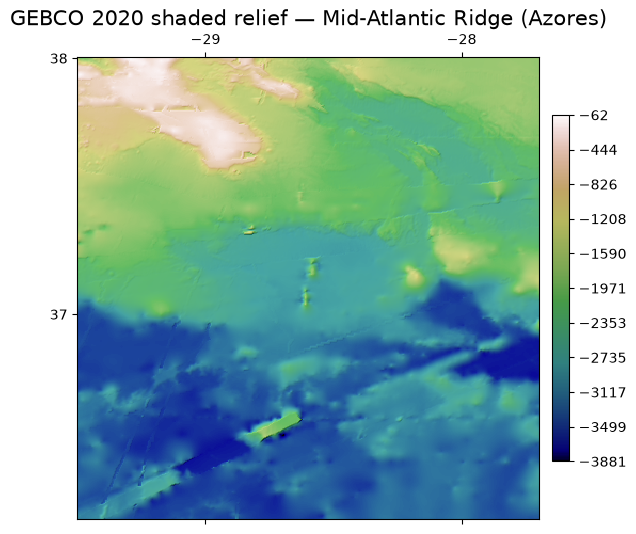

In [3]:
source.plot(
    cmap='gist_earth',
    data_style=DataStyle(
        hillshade={
            'azimuth': 315,
            'altitude': 45,
            'vert_exag': 1.0,
            'dx': 460,
            'dy': 460,
            'blend_mode': 'soft',
        }
    ),
    title='GEBCO 2020 shaded relief — Mid-Atlantic Ridge (Azores)',
)

## Off the flat page — Digital-Earth's 3-D tier

Hillshading fakes a third dimension by lighting a flat grid. `digitalearth.Scene3D` builds the actual
surface with PyVista, and `orbit` flies the camera around it.

Rotation is worth the frames **here** specifically. It pays when the terrain hides ground behind itself, and
this AOI does: the ridge spans 3,819 m of relief over 160 km — a ratio of about 1:42 — and at a 10 degree
camera elevation **3.4%** of the cells are occluded, varying by azimuth (3.0 / 4.6 / 2.9 / 3.1 %), so
different points on the circuit genuinely show different seafloor. A flat delta, by contrast, occludes
nothing at any angle, which is why the Copernicus-DEM notebook next door settles for a single still.

The camera is kept low, at 10 degrees: the same measurement says occlusion falls to 0.8% by 18 degrees and
0.2% by 30, so a steep look-down would throw away the very thing the fly-through is for. `shift` is derived
from that angle rather than guessed — the orbit radius is `factor * max(x_range, y_range)`, so
`shift = radius * tan(elevation)`.

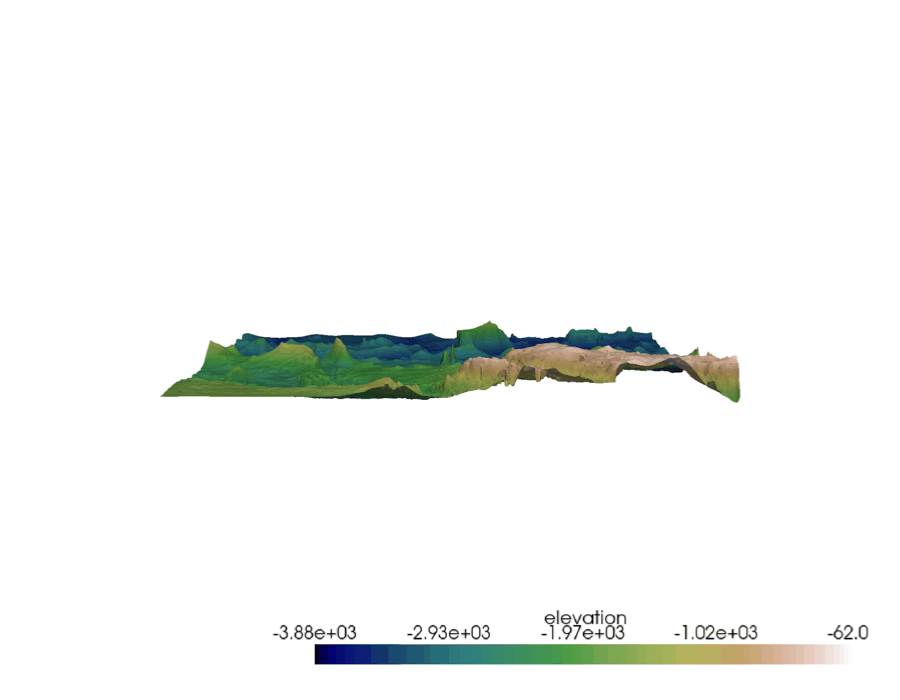

In [4]:
ELEVATION_DEG = 10.0  # low and raking: this is where the ridge occludes the most
FACTOR = 0.7

src = get_source(source)
extent = max(float(np.ptp(np.asarray(src.x.values))), float(np.ptp(np.asarray(src.y.values))))
shift = FACTOR * extent * math.tan(math.radians(ELEVATION_DEG))

scene = Scene3D(off_screen=True, window_size=(900, 700))
# 8x vertical exaggeration, not the 40x a delta needs -- this ridge has real relief.
scene.terrain(src, z_exaggeration=8.0, cmap='gist_earth')
ridge_gif = scene.orbit(
    str(Path(out) / 'azores_ridge_orbit.gif'),
    n_frames=48,      # 48 frames at 8 fps is one revolution in six seconds
    framerate=8,
    factor=FACTOR,
    shift=shift,
)
scene.close()

display(Image(filename=ridge_gif))